# Establishing Comparability between the Shona Symptom Questionnaire

(SSQ-14) and the Patient Health Questionnaire (PHQ-9) as Depression Outcome Measures among Adolescents and Young Adults in South Africa

**Statistical Consideration and Analysis Results**

Marothi Peter Letsoalo [](https://orcid.org/https://orcid.org/0000-0003-2170-6312) (Africa Health Research Institute (AHRI))  
Nondumiso Thandiwe Mthiyani [](https://orcid.org/https://orcid.org/0000-0002-9881-7267) (Africa Health Research Institute (AHRI))

In [ ]:
## This chunk handles all package installations and loading for the factor analysis.
require(here)

Loading required package: here

here() starts at /Users/Marothi.Letsoalo/Library/CloudStorage/OneDrive-SharedLibraries-AHRI/Data Science Unit - Biostatistics/team_members/Marothi/projects/CO-LUMINATE/OBJ03-Psychometric

- The lockfile is already up to date.

Loading required package: conflicted

Loading required package: parallel

Loading required package: doParallel

Loading required package: foreach

Loading required package: iterators

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
Loading required package: labelled

Loading required package: reshape2

Loading required package: gtsummary

Loading required package: gt

Loading required package: gtreg

Loading required package: BiocManager

Loading required package: htmltools
Loading required package: ComplexUpset
Loading required package: ggstatsplot
You can cite this package as:
     Patil, I. (2021). Visualizations with statistical details: The 'ggstatsplot' approach.
     Journal of Open Source Software, 6(61), 3167, doi:10.21105/joss.03167
Loading required package: scales
Loading required package: ggsci
Loading required package: patchwork
Loading required package: psych
Loading required package: lavaan
This is lavaan 0.6-20
lavaan is FREE software! Please report any bugs.
Loading required package: semTools
 
###############################################################################
This is semTools 0.5-7
All users of R (or SEM) are invited to submit functions or ideas for functions.
###############################################################################
Loading required package: pROC
Type 'citation("pROC")' for a citation.

- The lockfile is already up to date.

In [ ]:
## This chunk sets global options for figures and tables
theme_gtsummary_compact()

Setting theme "Compact"

Setting theme "JAMA"

In [ ]:
## Load datasets
load(file=here("../../data_management/data/co-luminate/adam/dt_psychometric.RData"))
load(file=here("../../data_management/data/co-luminate/adam/dt_disposition.RData"))
load(file=here("../../data_management/data/co-luminate/adam/dt_concordance.RData"))
load(file=here("../../data_management/data/co-luminate/adam/dt_to_score.RData"))

In [ ]:
# Create directory for statistical analysis
# Define the root directory name
root_dir <- here("statistical_analysis")

# Define the full list of directories to create
# Use file.path for OS-independent path construction
dirs_to_create <- c(
  file.path(root_dir, "data", "metadata"),
  file.path(root_dir, "data", "adam"),
  file.path(root_dir, "programs/analysis"),
  file.path(root_dir, "programs/utils"),
  file.path(root_dir, "models"),
  file.path(root_dir, "output", "table"),
  file.path(root_dir, "output", "figures"),
  file.path(root_dir, "output", "listing"),
  file.path(root_dir, "output", "objects")
)

# Create all directories recursively
# The 'showWarnings = FALSE' argument prevents warnings if the directories already exist
invisible(sapply(dirs_to_create, dir.create, recursive = TRUE, showWarnings = FALSE))

In [ ]:
# Source the Helper functions for Psychometric Bootstrap EFA Pipeline
source(here("statistical_analysis/programs/utils/Psych Run Pipeline.R"))

## Preliminary Analysis

This preliminary analysis evaluates the structural validity and stability of the Shona Symptom Questionnaire (SSQ-14) and two theoretically derived subsets: the SSQ-10 and the SSQ-08. This step serves as a critical foundation for subsequent work, specifically the derivation of an optimal cut-off score for the SSQ-10, referred to as the Theoretically Derived Depressive Symptoms scale, benchmarked against the PHQ-9.

Using a bootstrap resampling framework with 1,000 iterations, we sought to identify a stable factor structure that remains consistent across differing extraction criteria. Rather than viewing the traditional Kaiser Criterion and Parallel Analysis (PA) as competitors, this analysis interprets their results as complementary bounds. The Kaiser Criterion typically favors parsimony, potentially under-extracting, while PA is sensitive to distinct, latent dimensions, potentially extracting minor factors.

In [ ]:
# -----------------------------------------------------------------------------
# 7. Run Psychometric Bootstrap EFA Pipeline with Parallelization
# -----------------------------------------------------------------------------

data_name <- "analysis_ready_data"
dt_main   <- get(data_name)

n_boot_iterations <- 1000   # Consider testing with smaller first
n_pa_iterations   <- 100
cutoff_value      <- 0.4

item_sets_list <- list(
  "SSQ-14 (Original)"                         = paste0("SSQ", sprintf("%02d", 1:14)),
  "SSQ-10 (Theoretical Depressive Symptoms)" = paste0("SSQ", sprintf("%02d", c(1:3, 8:14))),
  "SSQ-08 (Dixon Chibanda et.al)"           = paste0("SSQ", sprintf("%02d", c(1, 8:14))),
  "PHQ-09 (Original)"                        = paste0("PHQ9", sprintf("%02d", 1:9))
)

main_results <- run_psychometric_pipeline(
  df_data       = dt_main,
  dataset_label = "Isisikelo Sempilo",
  item_sets_list = item_sets_list,
  n_boot        = n_boot_iterations,
  n_pa          = n_pa_iterations,
  loading_cutoff = cutoff_value,
  use_parallel   = TRUE,
  n_cores        = min(10,parallel::detectCores() - 4)
)

  STARTING ANALYSIS PIPELINE: Isisikelo Sempilo

Generated 3000 sets of split indices for Isisikelo Sempilo (includes buffer)


  Processing Item Set: SSQ-14 (Original)...

    Found existing saved results.

    Loading existing file (non-interactive mode).

    Loaded results from: /Users/Marothi.Letsoalo/Library/CloudStorage/OneDrive-SharedLibraries-AHRI/Data Science Unit - Biostatistics/team_members/Marothi/projects/CO-LUMINATE/OBJ03-Psychometric/statistical_analysis/output/objects/boot_1000_Isisikelo_Sempilo_SSQ-14_(Original)_results.rds


  Processing Item Set: SSQ-10 (Theoretical Depressive Symptoms)...

    Found existing saved results.

    Loading existing file (non-interactive mode).

    Loaded results from: /Users/Marothi.Letsoalo/Library/CloudStorage/OneDrive-SharedLibraries-AHRI/Data Science Unit - Biostatistics/team_members/Marothi/projects/CO-LUMINATE/OBJ03-Psychometric/statistical_analysis/output/objects/boot_1000_Isisikelo_Sempilo_SSQ-10_(Theoretical_Depressive_Symptoms)_results.rds


  Processing Item Set: SSQ-08 (Dixon Chibanda et.al)...

    Found existing saved results.

    Loading existing file (non-interactive mode).

    Loaded results from: /Users/Marothi.Letsoalo/Library/CloudStorage/OneDrive-SharedLibraries-AHRI/Data Science Unit - Biostatistics/team_members/Marothi/projects/CO-LUMINATE/OBJ03-Psychometric/statistical_analysis/output/objects/boot_1000_Isisikelo_Sempilo_SSQ-08_(Dixon_Chibanda_et.al)_results.rds


  Processing Item Set: PHQ-09 (Original)...

    Found existing saved results.

    Loading existing file (non-interactive mode).

    Loaded results from: /Users/Marothi.Letsoalo/Library/CloudStorage/OneDrive-SharedLibraries-AHRI/Data Science Unit - Biostatistics/team_members/Marothi/projects/CO-LUMINATE/OBJ03-Psychometric/statistical_analysis/output/objects/boot_1000_Isisikelo_Sempilo_PHQ-09_(Original)_results.rds

### Factor Retention Analysis: Determining the Stable Structure

The probability of retaining $k$ factors was calculated across 1,000 bootstrap iterations. We determined the most stable structure for each configuration by analyzing where the probabilities converged or presented a dominant model.

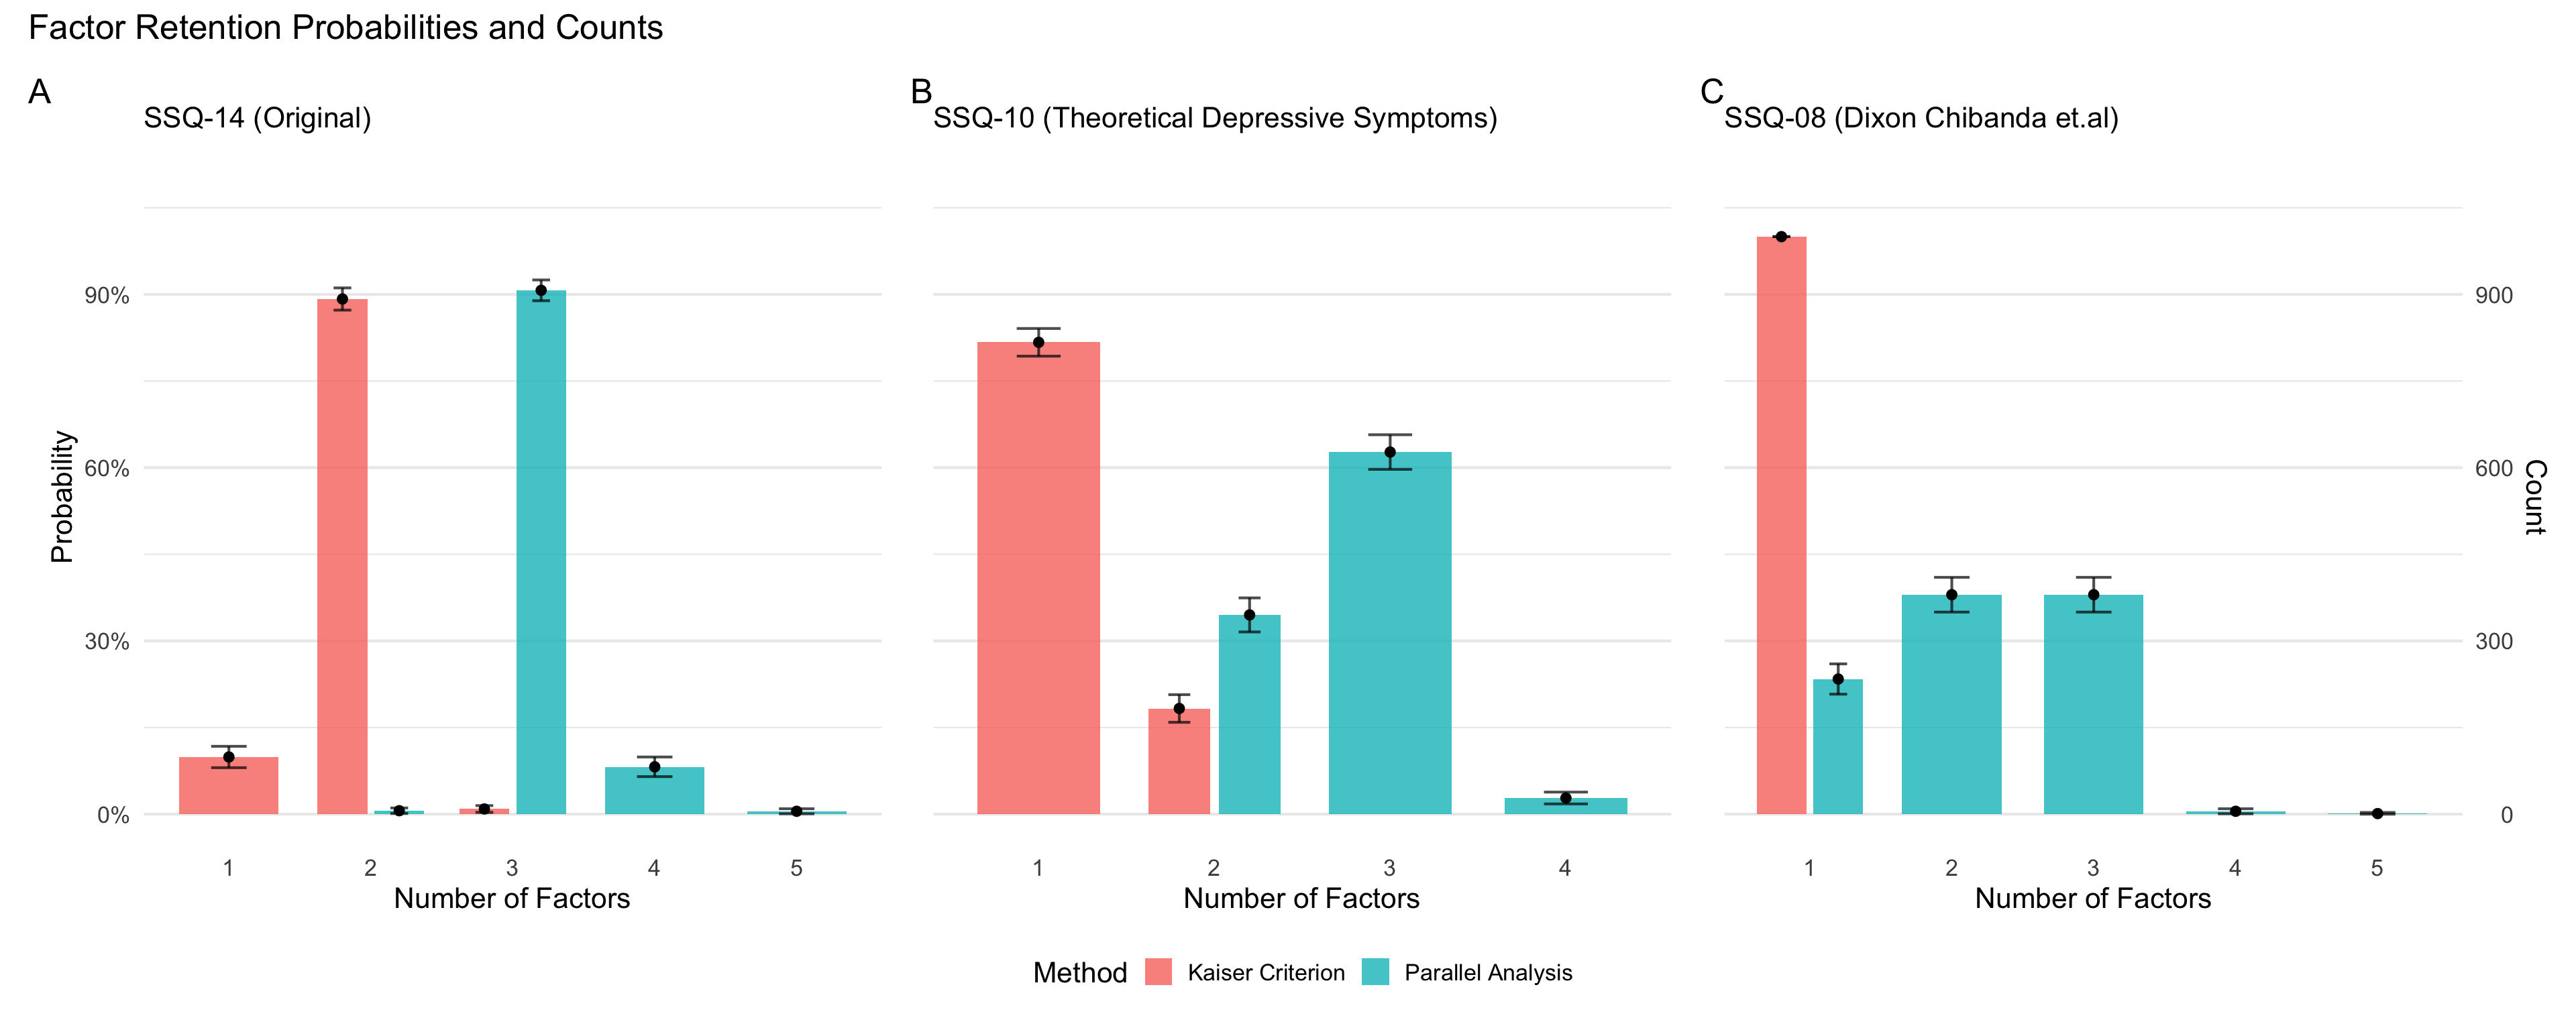

In [ ]:
retention_p1<-main_results[["SSQ-14 (Original)"]][["retention_analysis"]][["plot"]]
retention_p2<-main_results[["SSQ-10 (Theoretical Depressive Symptoms)"]][["retention_analysis"]][["plot"]]
retention_p3<-main_results[["SSQ-08 (Dixon Chibanda et.al)"]][["retention_analysis"]][["plot"]]

(
  (retention_p1
   )+
  (retention_p2
   )+
  (retention_p3
   )
  ) + 
  patchwork::plot_layout(guides = "collect",
                         axes = "collect_y") +
  patchwork::plot_annotation(title="Factor Retention Probabilities and Counts",
                         tag_level="A"
                  ) &
  
  ggplot2::theme_minimal(base_size = 16,
                         base_family = "Arial") & 
  ggplot2::labs() & 
  ggplot2::theme(
    legend.position = 'bottom',
    plot.caption = ggplot2::element_text(hjust = 0, size = 12, family = "Arial"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank()
    )

For the full scale, the Kaiser Criterion strongly favored a 2-factor solution with approximately 89.2% probability. Conversely, Parallel Analysis favored a 3-factor solution with 90.9% probability. These results indicate that the scale is robustly multidimensional. The 2-factor solution represents the most stable base structure, separating somatic from emotional symptoms, while the 3-factor solution represents a stable refinement of the emotional domain.

For the theoretical subset, the Kaiser Criterion overwhelmingly suggested a 1-factor solution in 81.7% of iterations. Parallel Analysis was more variable, favoring three factors in 62.2% of iterations but with significant support for two factors in 35.1% of cases. Given the known sensitivity of PA to minor factors and the strong consensus for one factor under the Kaiser Criterion, the 1-factor structure appears to be the most practical and stable configuration for this subset. The additional factors suggested by PA likely reflect minor correlations rather than substantive clinical dimensions.

For the SSQ-08 subset, the Kaiser Criterion universally suggested a 1-factor solution (100% probability). Parallel Analysis was ambiguous, splitting roughly evenly between 2-factor (37.9%) and 3-factor (37.2%) solutions, with a notable minority (24.4%) supporting a 1-factor solution. Based on these data, this subset is determined to be robustly uni-dimensional. The PA results likely reflect item doublets, or pairs of highly correlated items, rather than distinct latent constructs.

### Structural Stability and Item Co-occurrence

To validate these determinations, we examined the stability of item memberships within the winning models for each method.

#### SSQ-14 (Origina)

##### Kaiser Criterion (2-Factor Solution)

Under the Kaiser criterion, the scale splits cleanly into two distinct clusters. The high probabilities in the stability plot indicate very little cross-loading across iterations. The first factor, labeled General/Somatic, comprises items SSQ09 through SSQ14, which include hallucinations, suicide, and somatic complaints. The second factor, labeled Depressive/Anxious, includes items SSQ01 through SSQ08, encompassing symptoms such as thinking too much, sleep difficulties, and tearfulness. This confirms the scale measures two distinct but related constructs: general distress or somatic symptoms and core depression or anxiety.

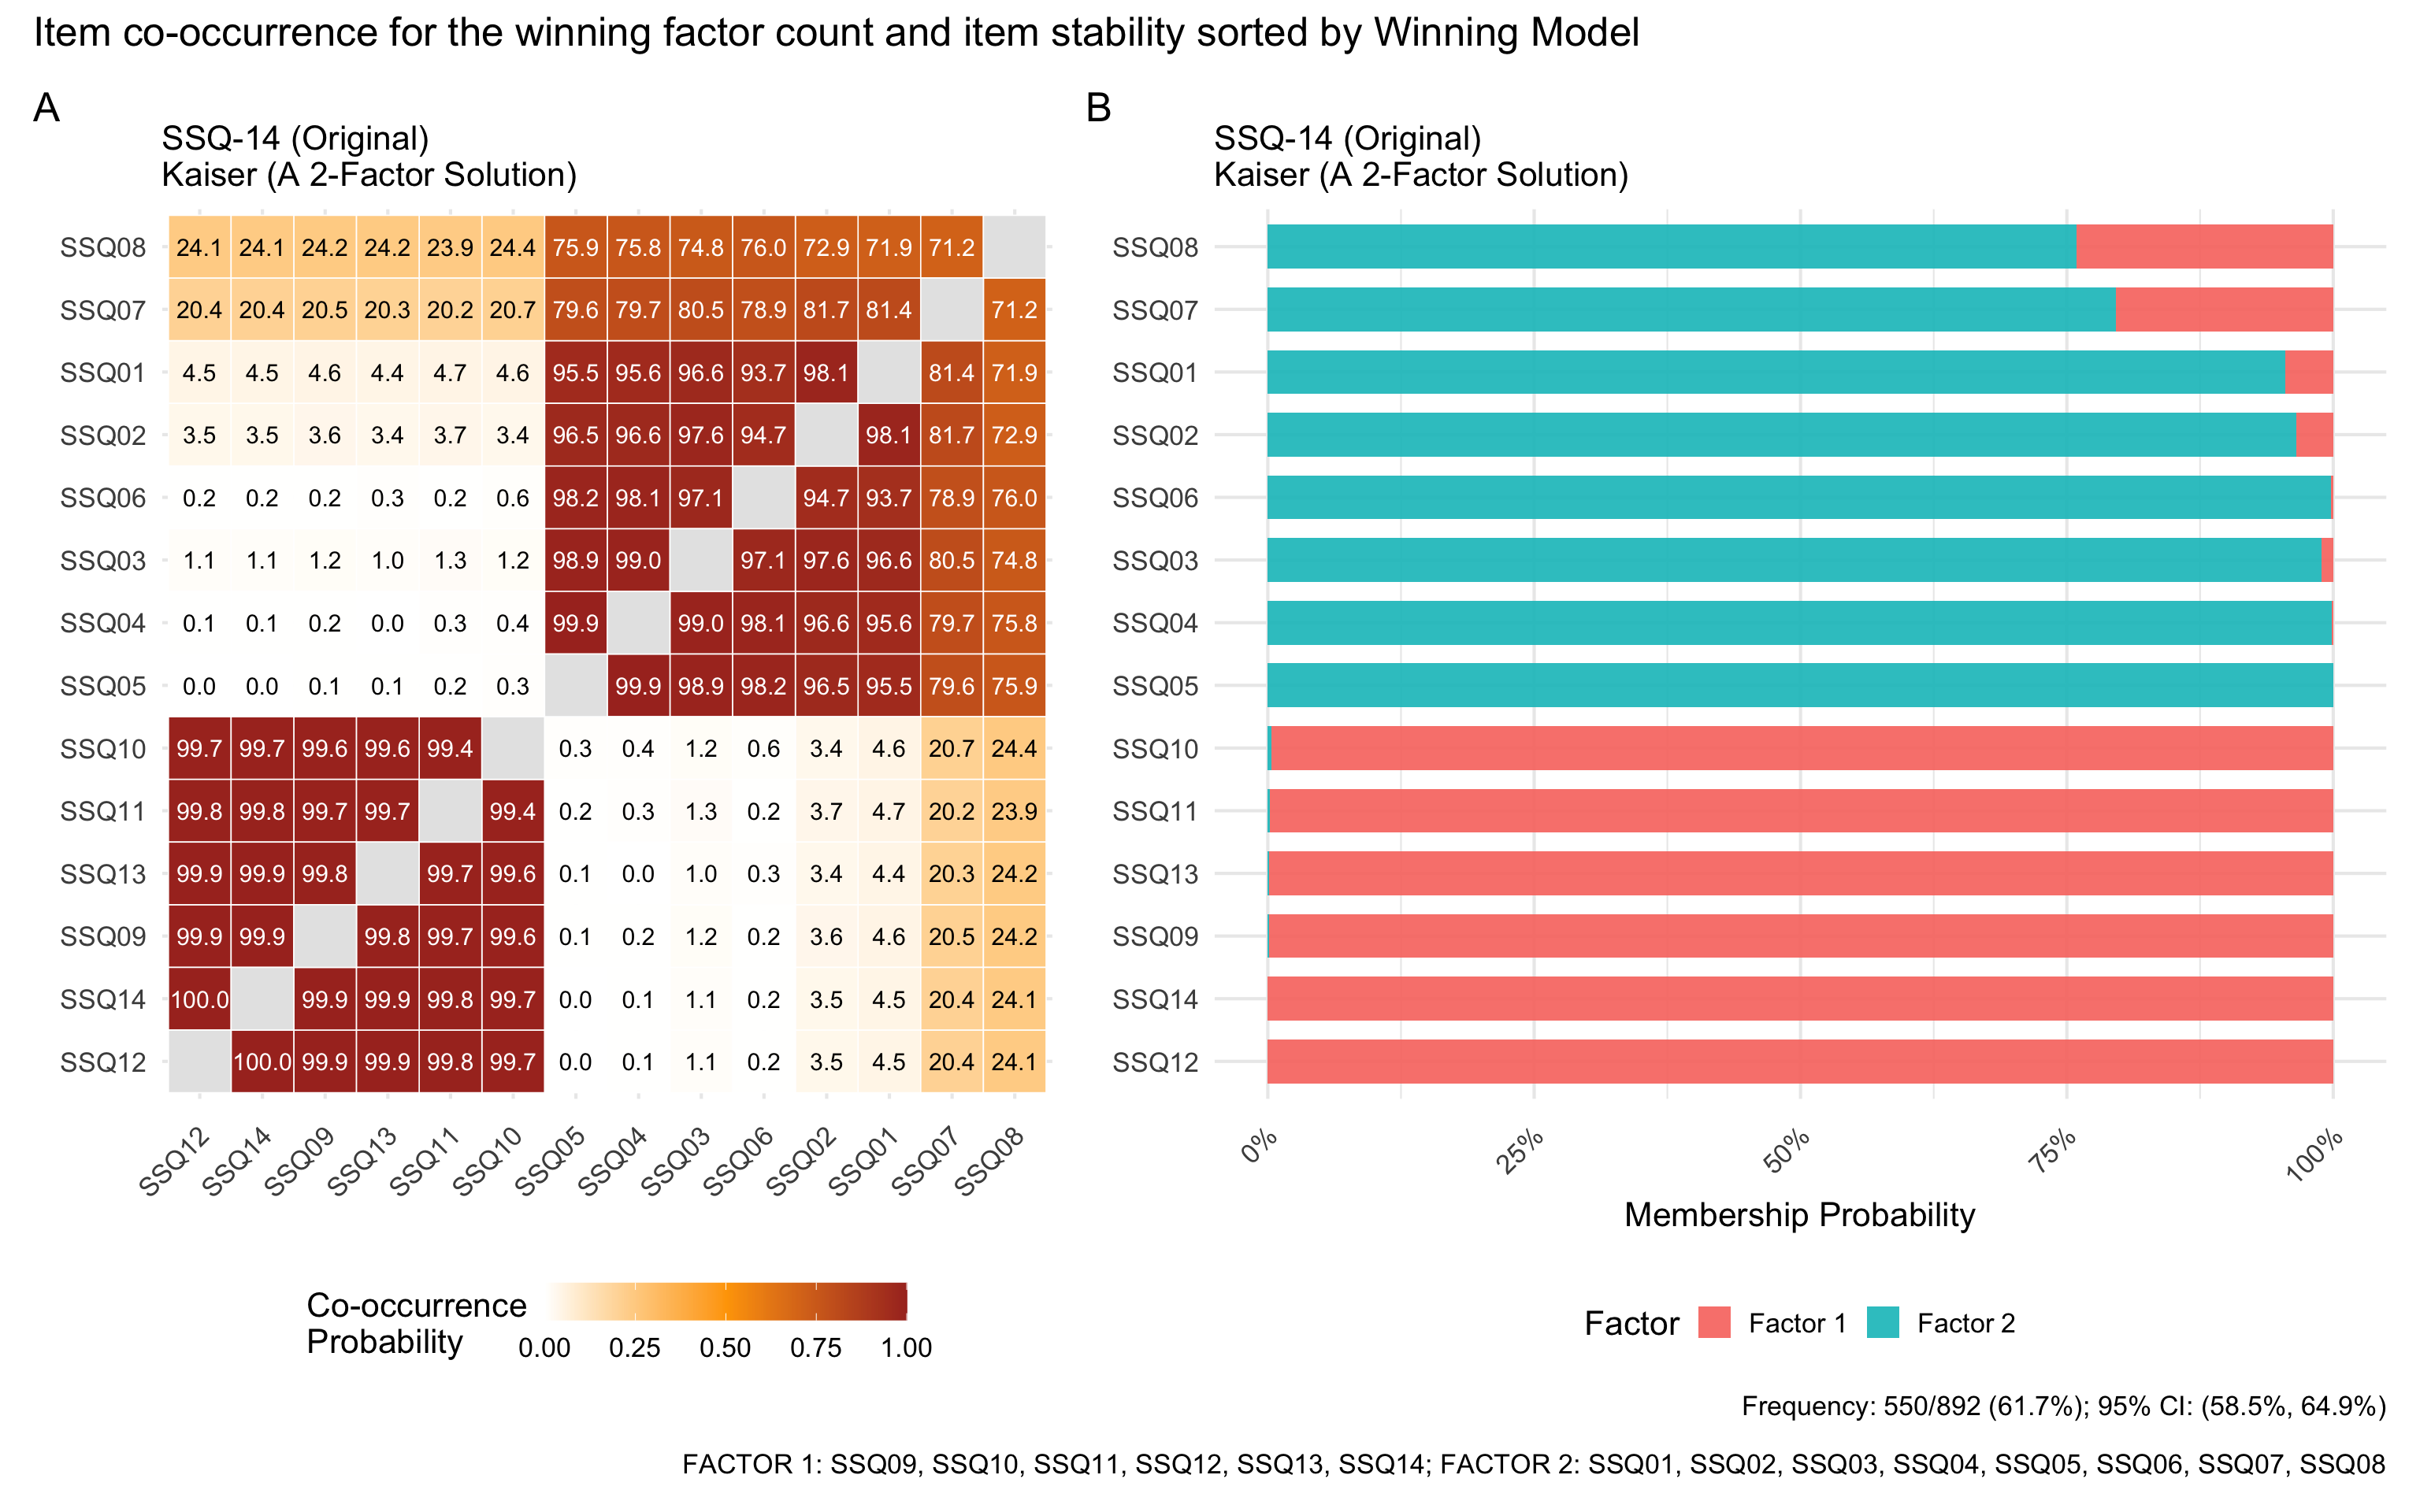

In [ ]:
cooccurrence_p<-main_results[["SSQ-14 (Original)"]][["cooccurrence"]][["Kaiser"]][["plot_heatmap"]]
stability_p<-main_results[["SSQ-14 (Original)"]][["cooccurrence"]][["Kaiser"]][["plot_stability"]]

((cooccurrence_p)+(stability_p)) + 
  patchwork::plot_layout() +
  patchwork::plot_annotation(title="Item co-occurrence for the winning factor count and item stability sorted by Winning Model",
                         tag_level="A"
                  ) &
  ggplot2::theme_minimal(base_size = 16) & 
  ggplot2::theme(legend.position = 'bottom',
                 axis.text.x  = ggplot2::element_text(angle = 45,vjust=.85,hjust=1),
                 )

In [ ]:
loadings_kaiser <- extract_loadings_long(main_results, "SSQ-14 (Original)", method = "Kaiser",factor_filter=2)
eigen_scree     <- extract_eigen_scree(main_results, "SSQ-14 (Original)")

##### Parallel Analysis (3-Factor Solution)

Parallel Analysis consistently splits the Depressive factor further. The first factor remains the Somatic/Severe dimension, comprising items SSQ07 and SSQ09 through SSQ14. A second factor, labeled Core Depression, includes items SSQ01 through SSQ03. A third factor, labeled Cognitive/Anxiety, includes items SSQ04 through SSQ06 and SSQ08. While stable, this granularity may offer less clinical utility than the 2-factor solution depending on the intended use.

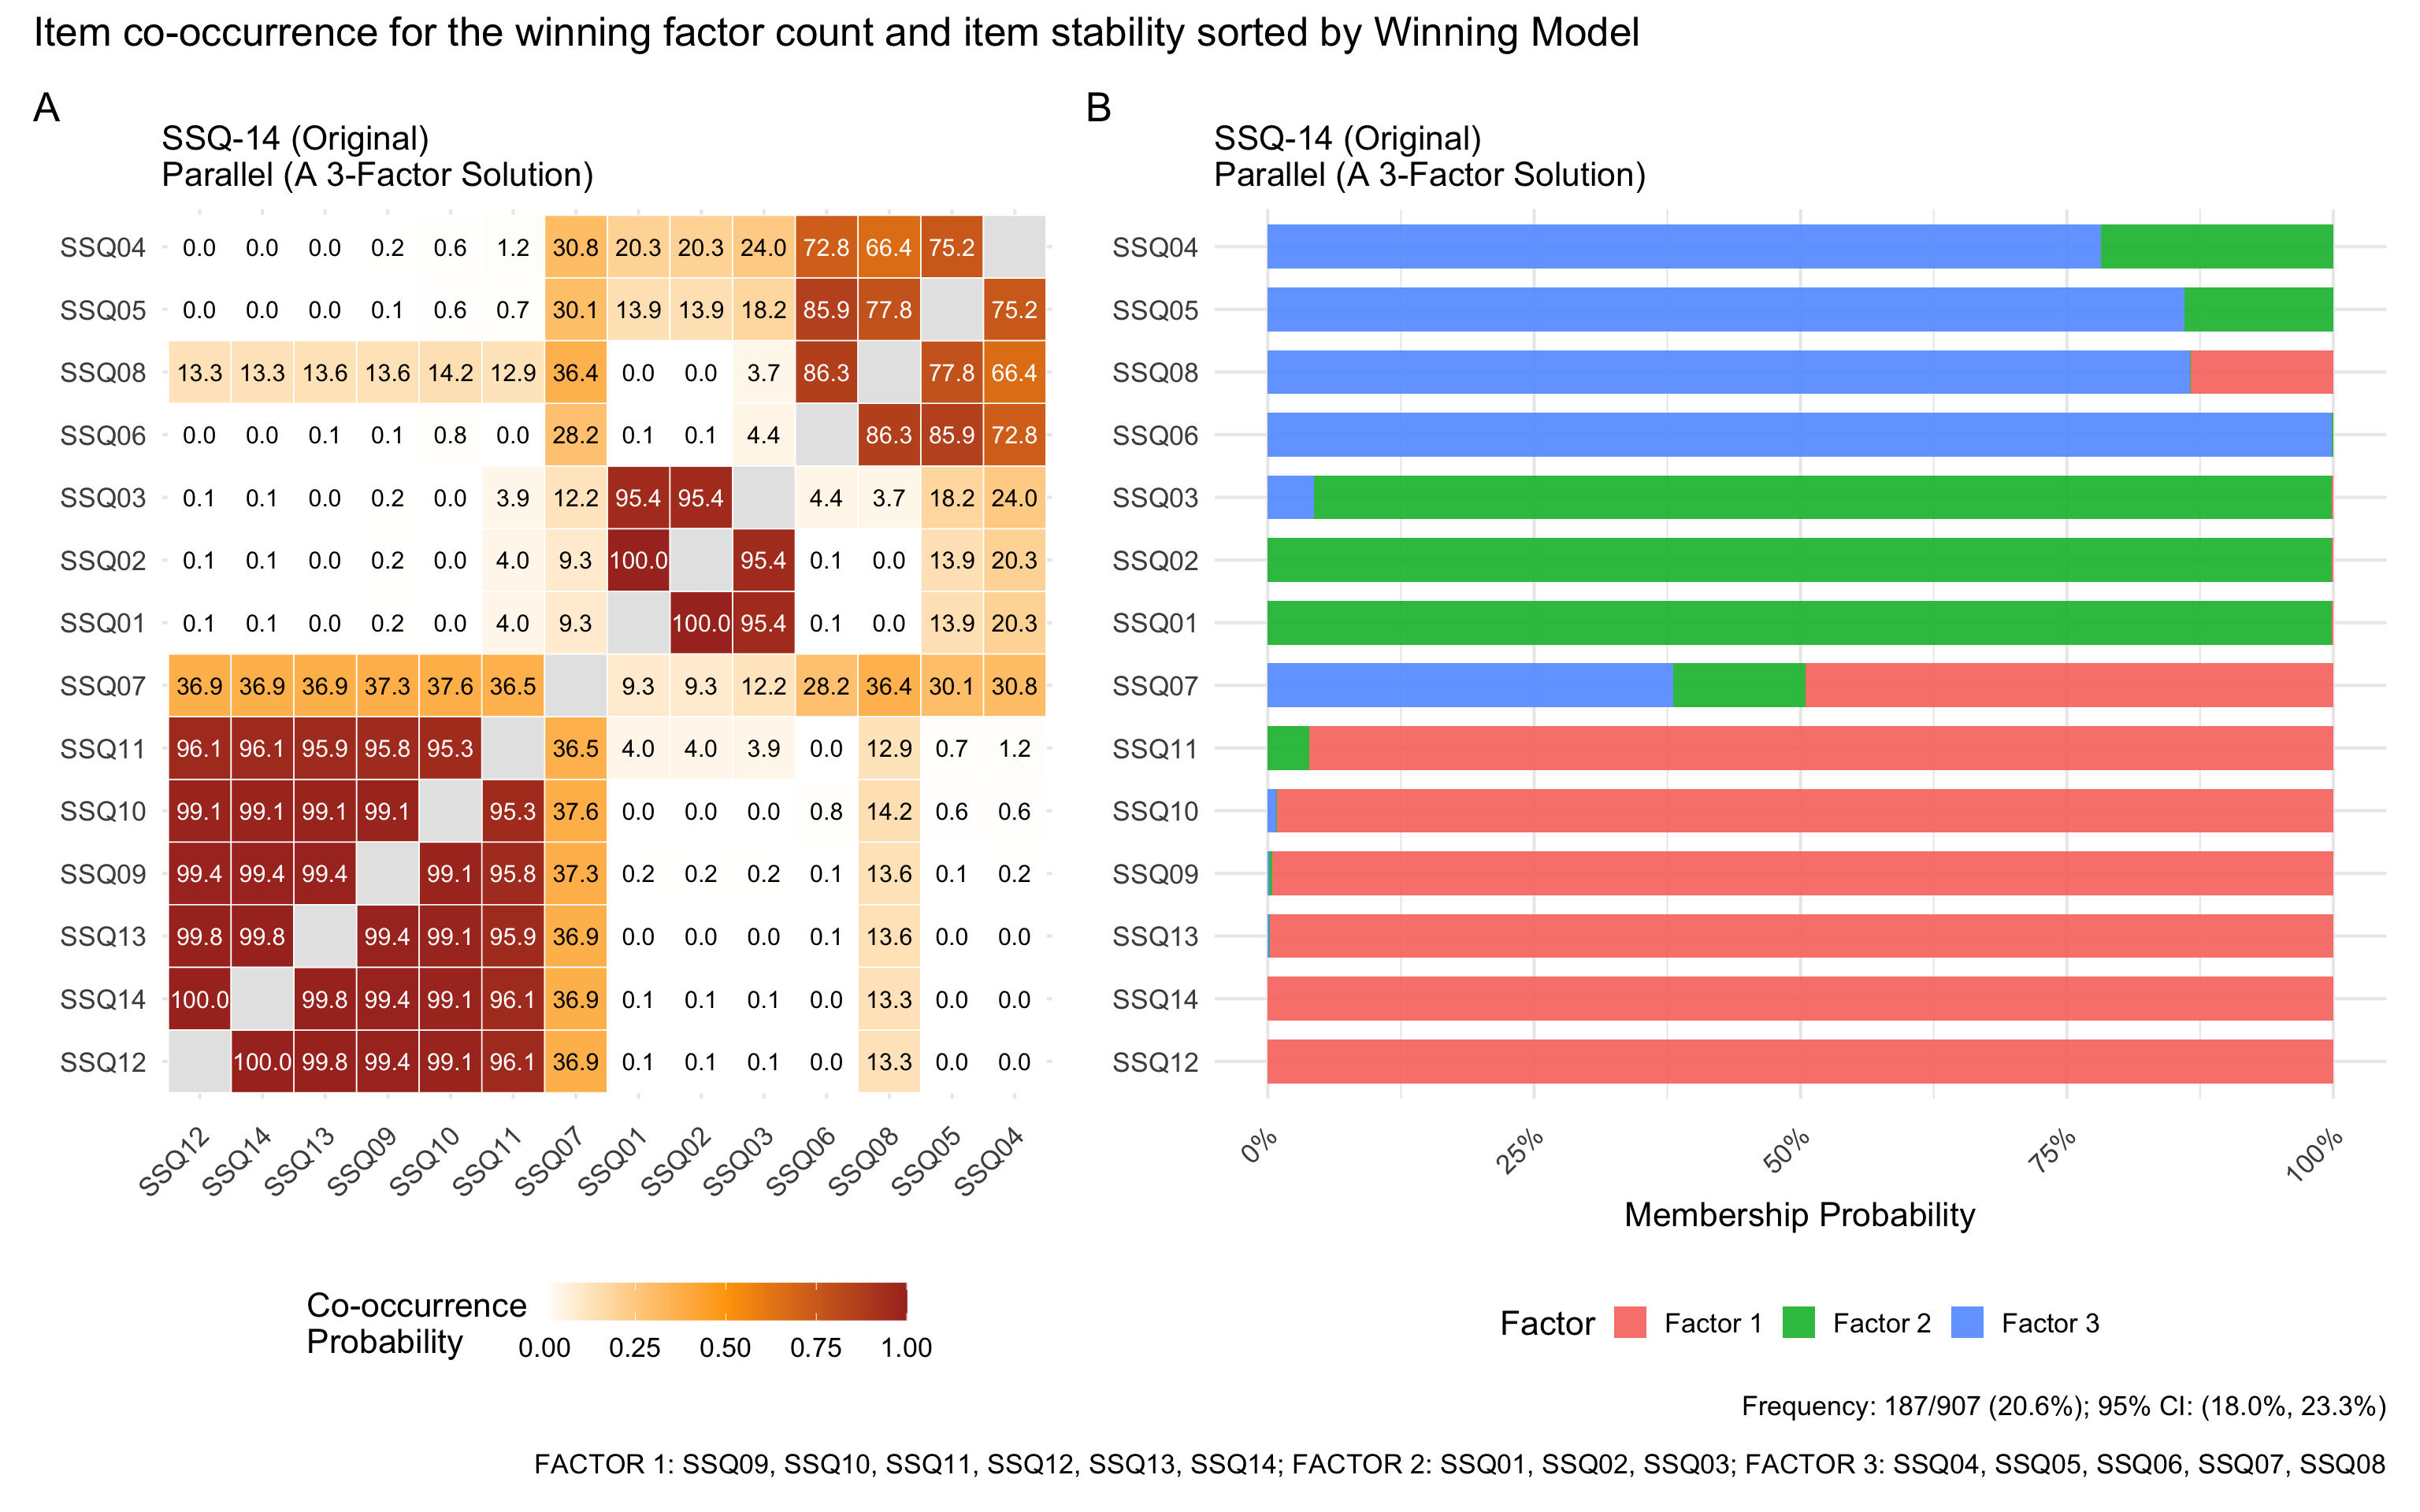

In [ ]:
cooccurrence_p<-main_results[["SSQ-14 (Original)"]][["cooccurrence"]][["Parallel"]][["plot_heatmap"]]
stability_p<-main_results[["SSQ-14 (Original)"]][["cooccurrence"]][["Parallel"]][["plot_stability"]]

((cooccurrence_p)+(stability_p)) + 
  patchwork::plot_layout() +
  patchwork::plot_annotation(title="Item co-occurrence for the winning factor count and item stability sorted by Winning Model",
                         tag_level="A"
                  ) &
  ggplot2::theme_minimal(base_size = 16) & 
  ggplot2::theme(legend.position = 'bottom',
                 axis.text.x  = ggplot2::element_text(angle = 45,vjust=.85,hjust=1),
                 )

#### SSQ-10 (Theoretical Subset)

This subset excludes items SSQ04 through SSQ07 to focus on depressive symptoms. Although the Kaiser Criterion supports a 1-factor model, examining the Parallel Analysis 3-factor solution reveals why a 1-factor model might be superior for this subset.

##### Parallel Analysis (3-Factor Solution)

The structure under PA reveals three factors. The first factor includes items SSQ09 through SSQ14, representing severe symptoms. The second factor includes items SSQ01 through SSQ03, representing core emotional symptoms. The third factor consists solely of item SSQ08, representing fatigue or work lag. The emergence of SSQ08 as a singleton or weakly associated factor in the 3-factor solution suggests structural fragmentation. This supports the decision to treat the SSQ-10 as a uni-dimensional scale, as suggested by the Kaiser Criterion, for the purpose of establishing a depression cut-off, as dividing it further creates unstable, item-specific factors.

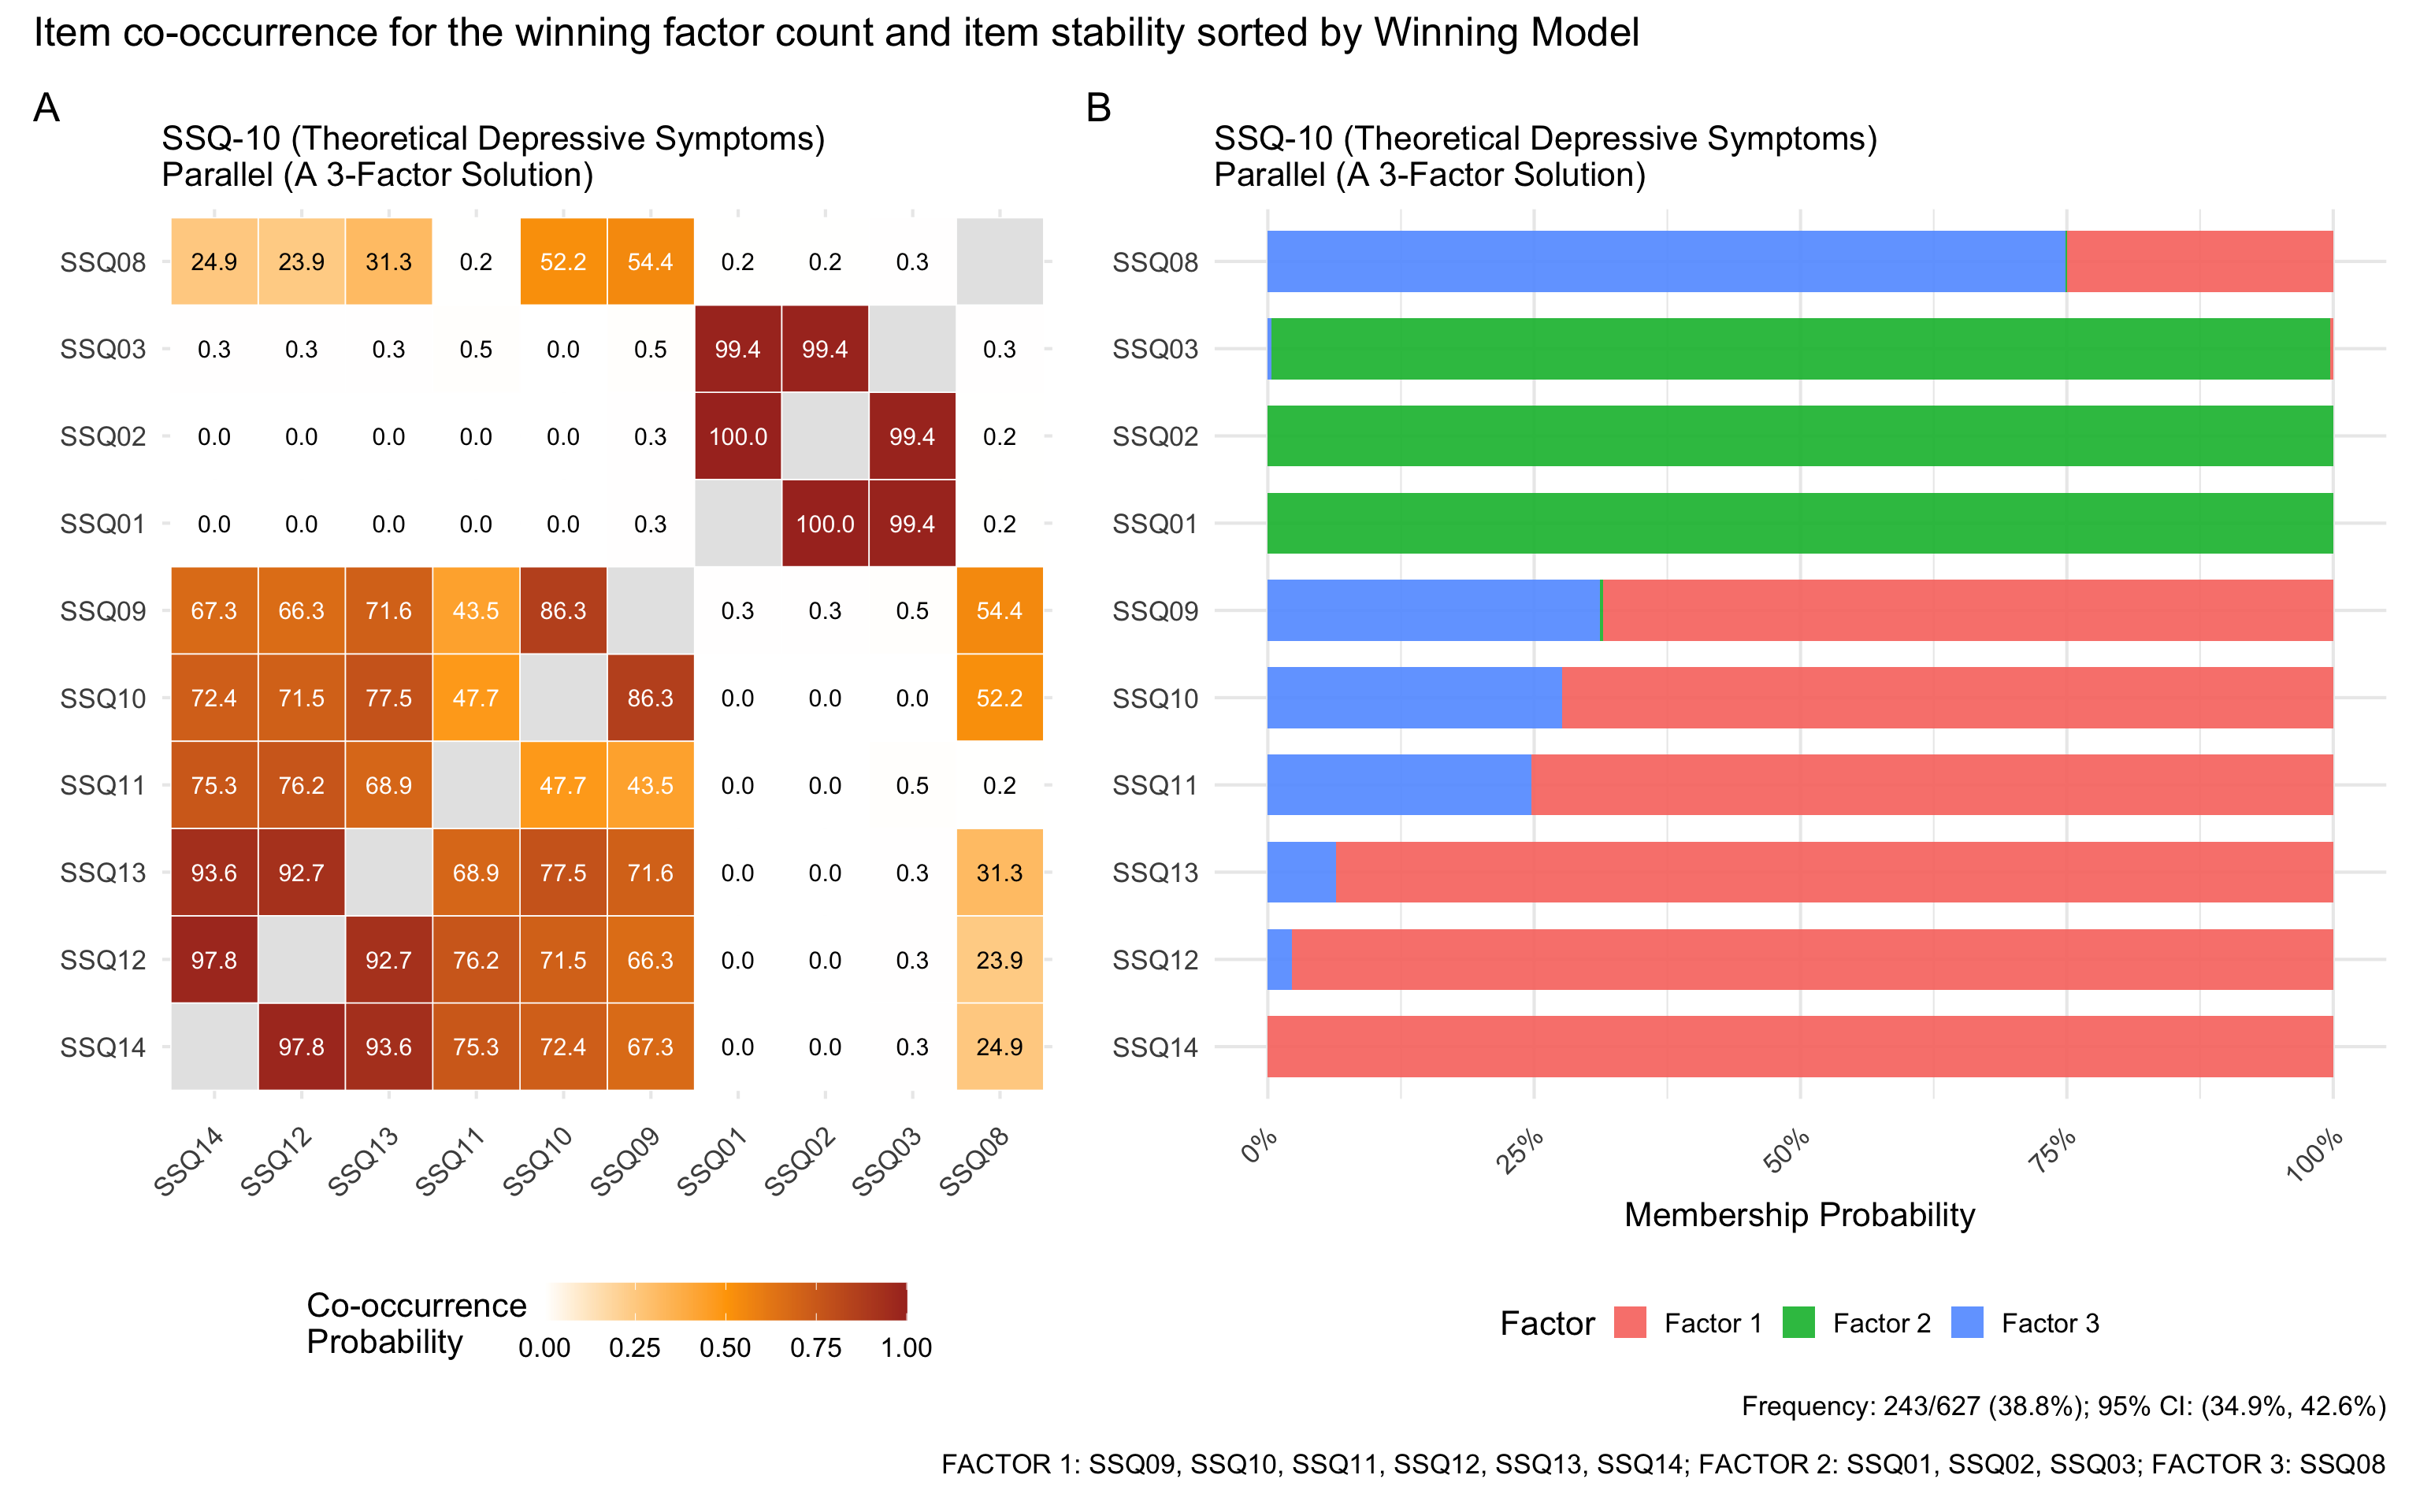

In [ ]:
cooccurrence_p<-main_results[["SSQ-10 (Theoretical Depressive Symptoms)"]][["cooccurrence"]][["Parallel"]][["plot_heatmap"]]
stability_p<-main_results[["SSQ-10 (Theoretical Depressive Symptoms)"]][["cooccurrence"]][["Parallel"]][["plot_stability"]]

((cooccurrence_p)+(stability_p)) + 
  patchwork::plot_layout() +
  patchwork::plot_annotation(title="Item co-occurrence for the winning factor count and item stability sorted by Winning Model",
                         tag_level="A"
                  ) &
  ggplot2::theme_minimal(base_size = 16) & 
  ggplot2::theme(legend.position = 'bottom',
                 axis.text.x  = ggplot2::element_text(angle = 45,vjust=.85,hjust=1),
                 )

#### SSQ-08 (Dixon-Chibanda Subset)

Similarly, while the Kaiser Criterion identifies one factor, the Parallel Analysis 2-factor solution demonstrates instability.

##### Parallel Analysis (2-Factor Solution)

The structure under the PA 2-factor model splits the items into two groups. Factor 1 contains items SSQ11 through SSQ14. Factor 2 contains items SSQ01, SSQ08, SSQ09, and SSQ10. The co-occurrence heatmap shows fuzziness for Factor 2 items, indicating they do not cluster together as reliably as Factor 1 items. This lack of cohesion under the PA 2-factor model reinforces the conclusion that the 1-factor model identified by the Kaiser Criterion is the most accurate representation of the SSQ-08 structure.

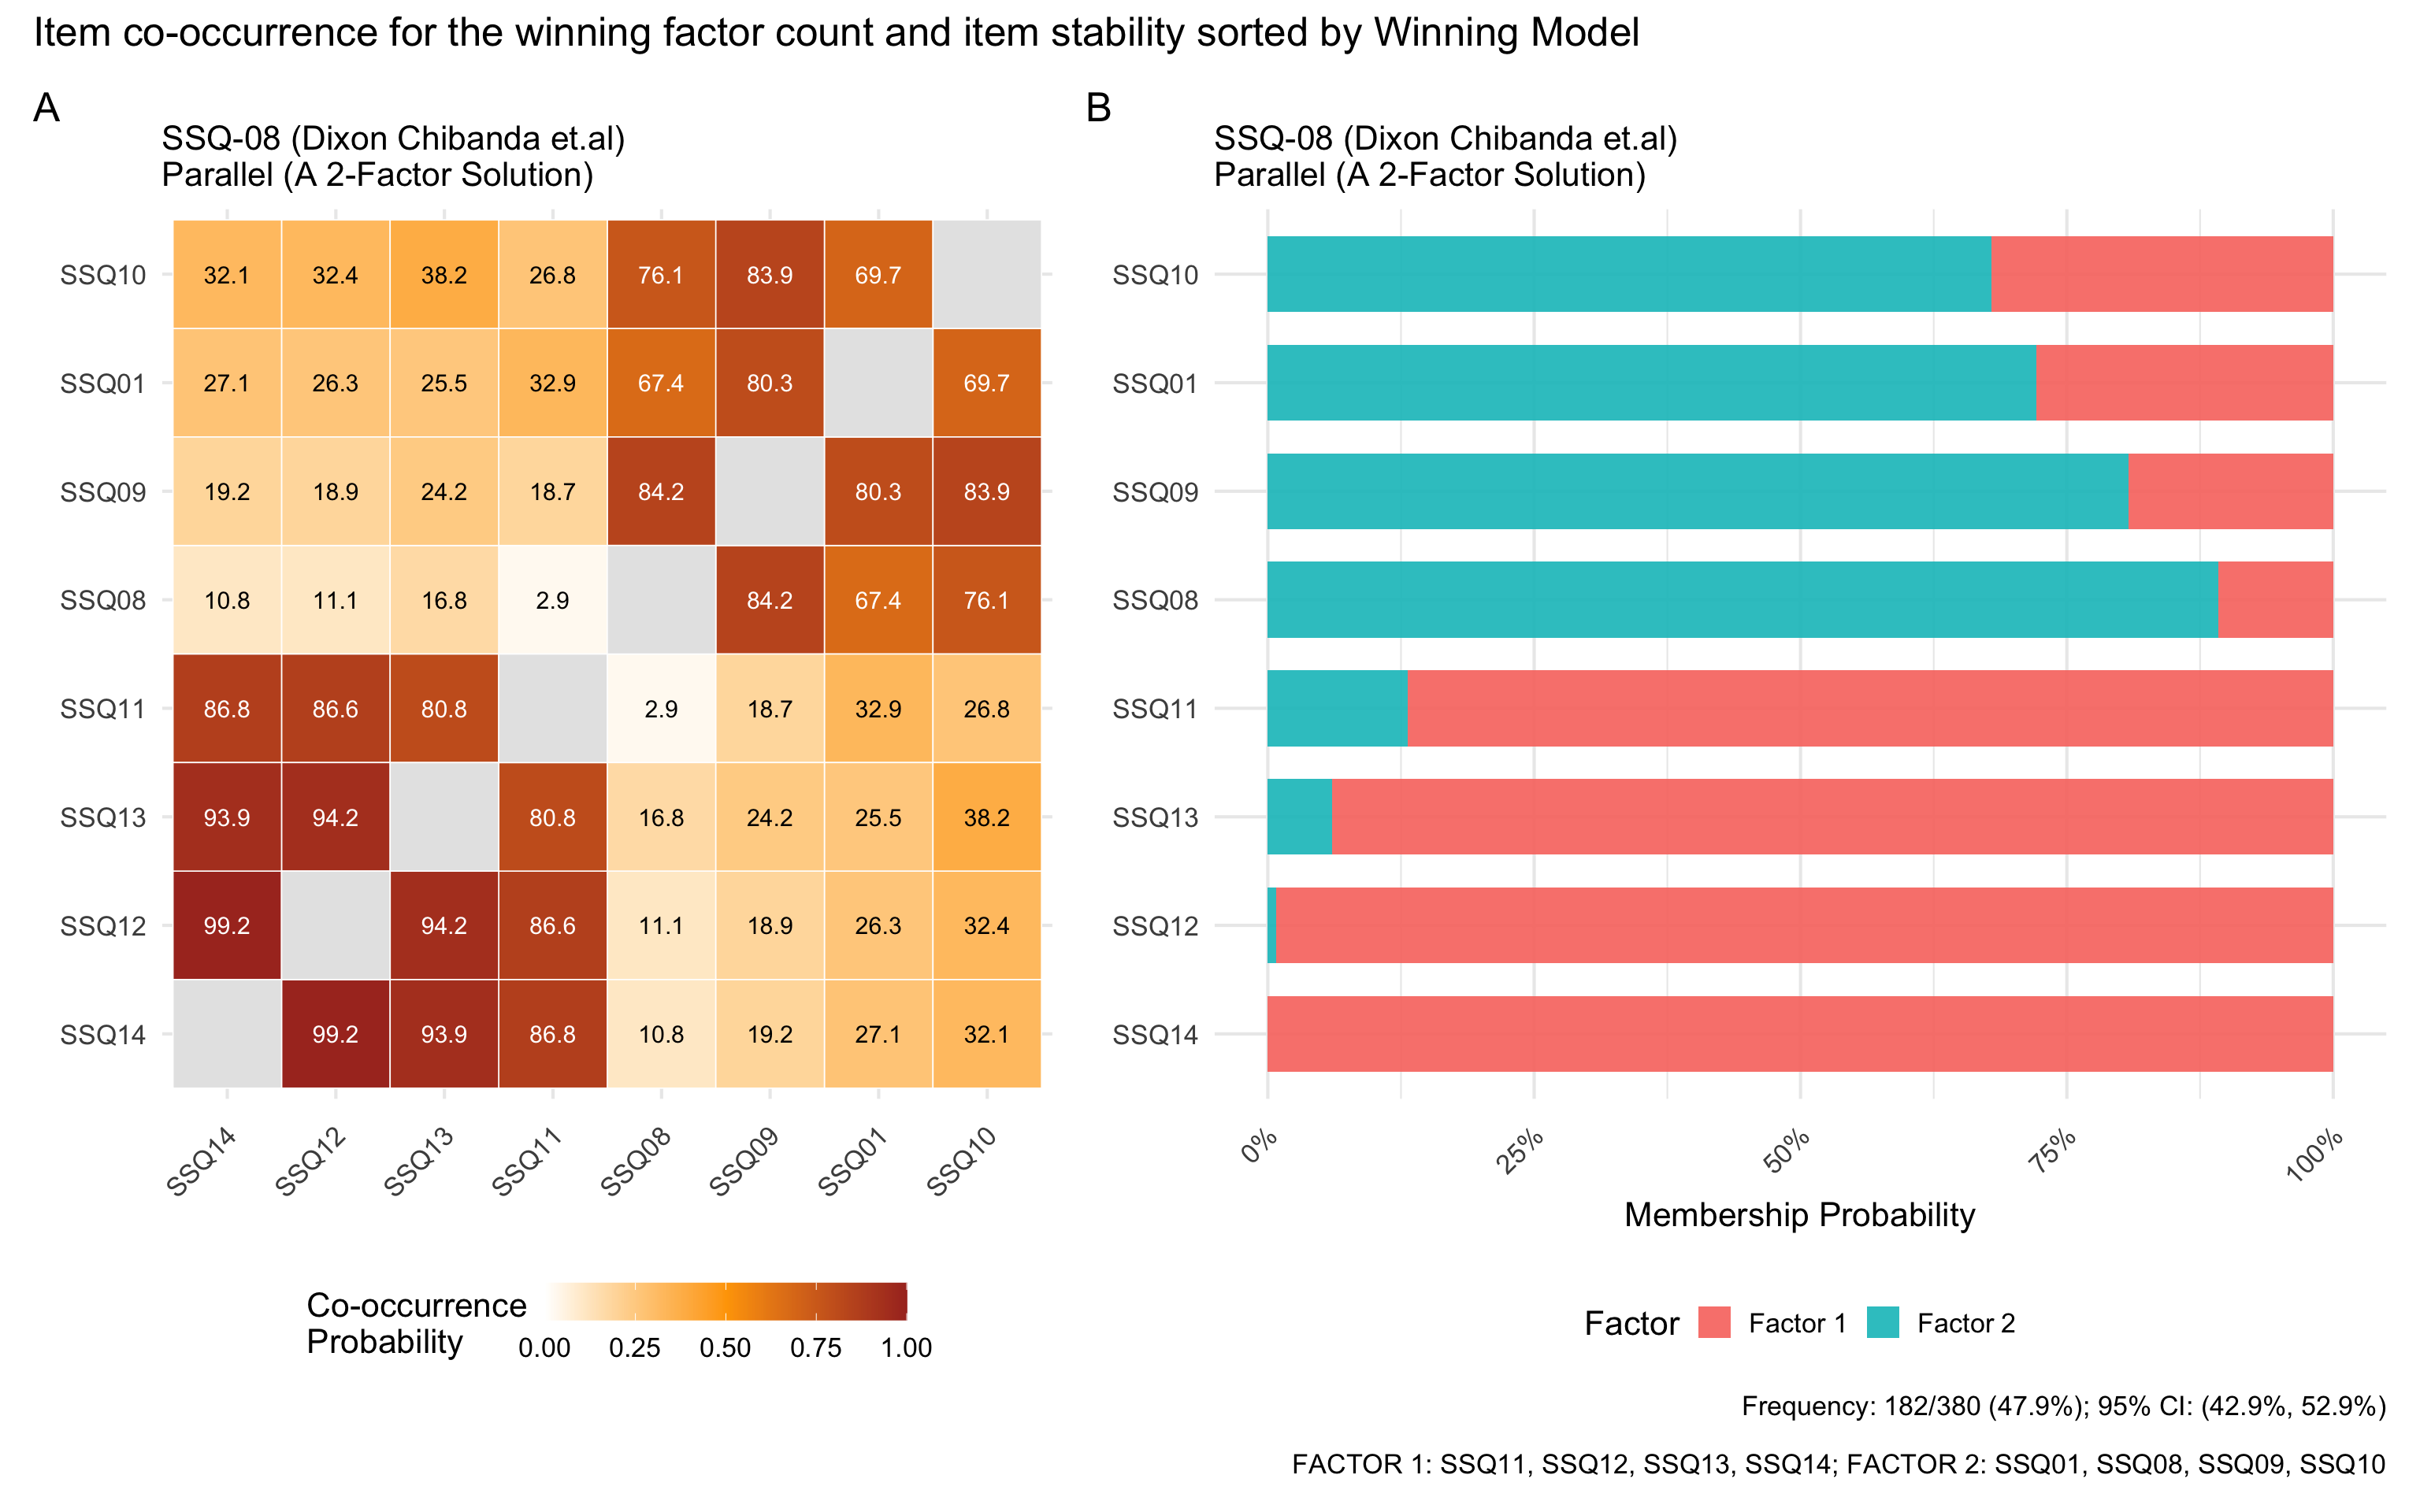

In [ ]:
cooccurrence_p<-main_results[["SSQ-08 (Dixon Chibanda et.al)"]][["cooccurrence"]][["Parallel"]][["plot_heatmap"]]
stability_p<-main_results[["SSQ-08 (Dixon Chibanda et.al)"]][["cooccurrence"]][["Parallel"]][["plot_stability"]]

((cooccurrence_p)+(stability_p)) + 
  patchwork::plot_layout() +
  patchwork::plot_annotation(title="Item co-occurrence for the winning factor count and item stability sorted by Winning Model",
                         tag_level="A"
                  ) &
  ggplot2::theme_minimal(base_size = 16) & 
  ggplot2::theme(legend.position = 'bottom',
                 axis.text.x  = ggplot2::element_text(angle = 45,vjust=.85,hjust=1),
                 )

#### PHQ-09 (Original)

##### Parallel Analysis (3-Factor Solution)

Although Kaiser strongly supports a 1-factor model, the PA 3-factor solution (Frequency: 209/374 valid runs) reveals a coherent tripartite substructure. Factor 1 (Cognitive/Severe) includes PHQ906–909 (Guilt, Concentration, Motor, Suicide). Factor 2 (Somatic) includes PHQ903–905 (Sleep, Energy, Appetite). Factor 3 (Core Affective) includes PHQ901–902 (Anhedonia, Mood). While this substructure is theoretically interpretable, the low overall stability and high rate of model non-convergence in bootstrapping support using the robust 1-factor structure for the primary clinical objective.

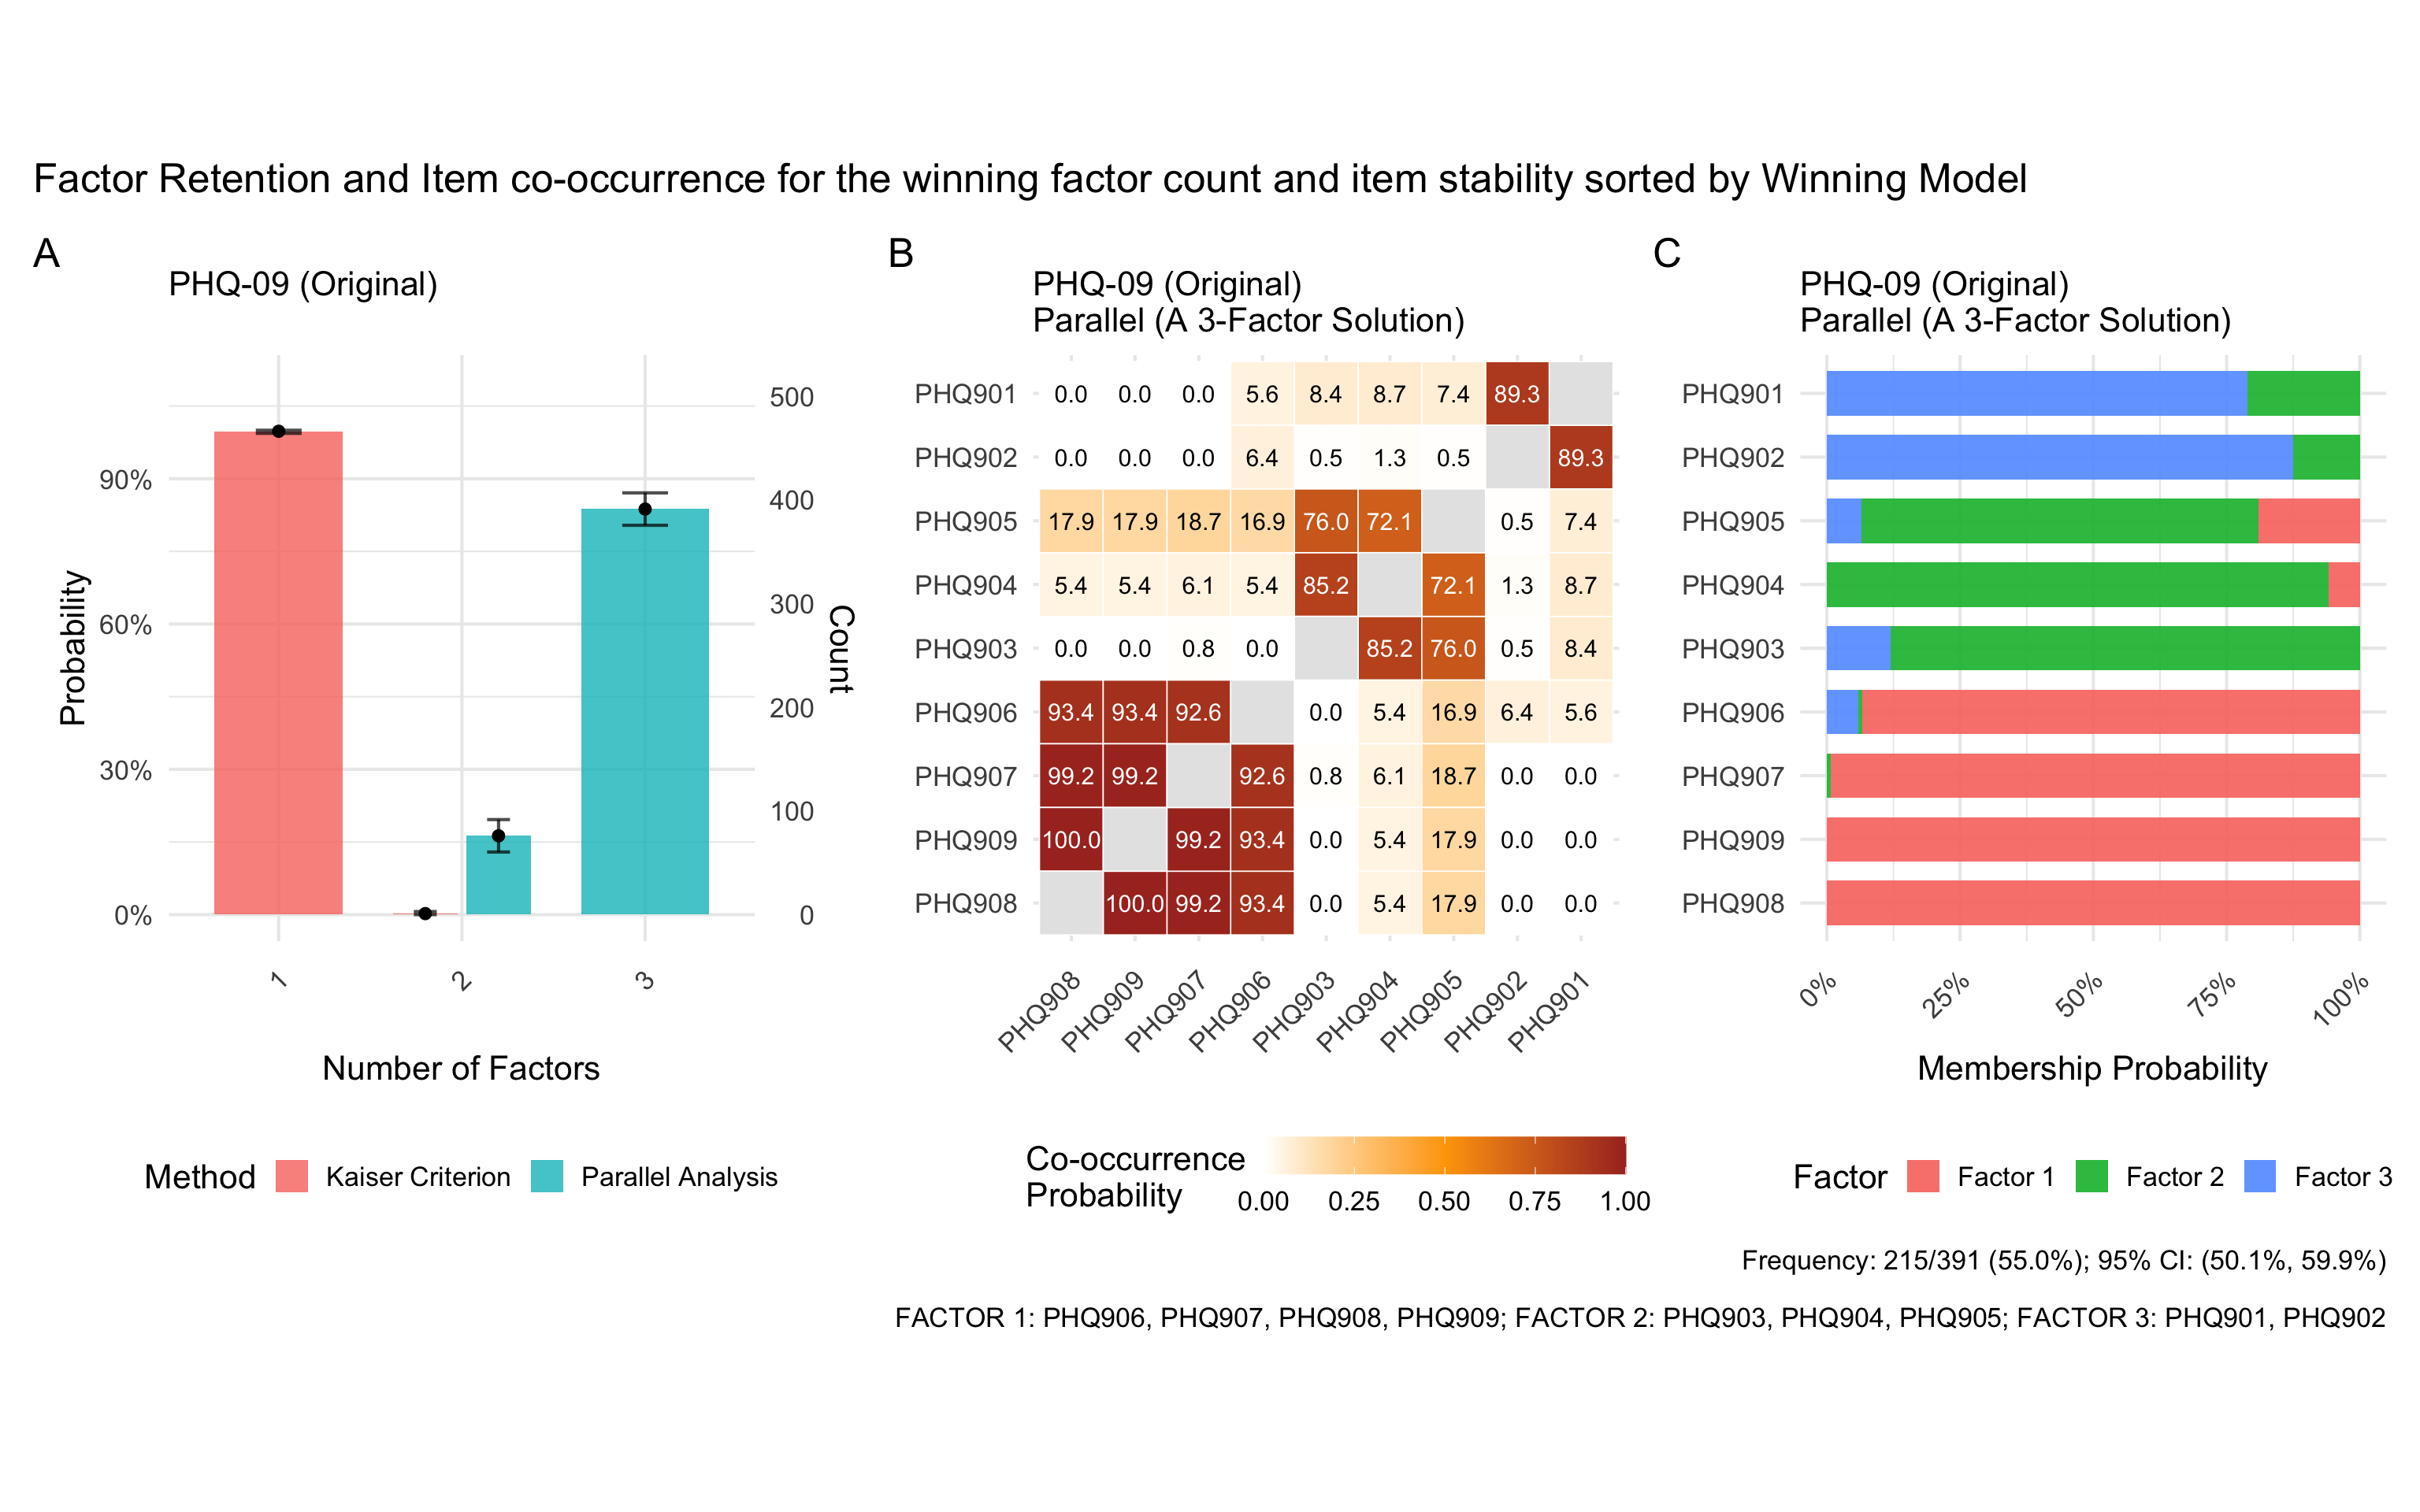

In [ ]:
retention_p<-main_results[["PHQ-09 (Original)"]][["retention_analysis"]][["plot"]]
cooccurrence_p<-main_results[["PHQ-09 (Original)"]][["cooccurrence"]][["Parallel"]][["plot_heatmap"]]
stability_p<-main_results[["PHQ-09 (Original)"]][["cooccurrence"]][["Parallel"]][["plot_stability"]]

((retention_p)+(cooccurrence_p)+(stability_p)) + 
  patchwork::plot_layout() +
  patchwork::plot_annotation(title="Factor Retention and Item co-occurrence for the winning factor count and item stability sorted by Winning Model",
                         tag_level="A"
                  ) &
  ggplot2::theme_minimal(base_size = 16) & 
  ggplot2::theme(legend.position = 'bottom',
                 axis.text.x  = ggplot2::element_text(angle = 45,vjust=.85,hjust=1),
                 )